In [55]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [56]:
df=pd.read_csv('Blood_Glucose.csv')
df.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0.0,0.0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1.0,0.0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1.0,0.0,N
3,9.0,F,NaN,78.0,High,115.0,96.0,98.300707,NaN,NaN,NaN,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0.0,0.0,N


In [57]:
df.shape

(16969, 12)

In [58]:
df.isnull().sum()
df.duplicated().sum()

np.int64(146)

In [59]:
df.columns

Index(['Age', 'Gender', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Diastolic Blood Pressure Level', 'Systolic Blood Pressure',
       'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)',
       'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)'],
      dtype='object')

In [60]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16969 entries, 0 to 16968
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             16969 non-null  float64
 1   Gender                          16877 non-null  object 
 2   Blood Glucose Reading           16121 non-null  float64
 3   Diastolic Blood Pressure        16950 non-null  float64
 4   Diastolic Blood Pressure Level  16950 non-null  object 
 5   Systolic Blood Pressure         16969 non-null  float64
 6   Heart Rate                      16969 non-null  float64
 7   Body Temperature                16735 non-null  float64
 8   SPO2                            16121 non-null  float64
 9   Sweating  (Y/N)                 16121 non-null  float64
 10  Shivering (Y/N)                 16121 non-null  float64
 11  Diabetic/NonDiabetic (D/N)      16969 non-null  object 
dtypes: float64(9), object(3)
memory 

In [61]:
df.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,16969.000000,16121.000000,16950.000000,16969.000000,16969.000000,16735.000000,16121.000000,16121.000000,16121.000000
mean,30.982209,95.719219,77.172537,118.183029,91.505045,97.359325,97.380645,0.121493,0.145481
std,29.736598,49.947465,8.414652,8.947304,12.084934,0.814258,0.986455,0.379650,0.409722
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436,-1.838546,-1.970002
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,83.000000,76.000000,118.000000,89.000000,97.331641,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.953929,98.000000,0.000000,0.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288,2.081459,2.260927


In [62]:
# Get all duplicate-related rows: original + duplicate copies
dup_cols = df.columns.tolist()

duplicates_all = df[df.duplicated(keep=False)].copy()

# Create duplicate group number
duplicates_all['Duplicate_Group'] = duplicates_all.groupby(
    dup_cols,
    dropna=False
).ngroup() + 1

# Create copy number inside each duplicate group
duplicates_all['Copy_Number'] = duplicates_all.groupby('Duplicate_Group').cumcount() + 1

# Mark first row as Original, others as Duplicate
duplicates_all['Row_Type'] = duplicates_all['Copy_Number'].apply(
    lambda x: 'Original' if x == 1 else 'Duplicate'
)

# Show original index also
duplicates_all = duplicates_all.reset_index(names='Original_Index')

# Sort so original and duplicates come up/down together
duplicates_all = duplicates_all.sort_values(
    by=['Duplicate_Group', 'Copy_Number']
)

duplicates_all

df = df.drop_duplicates().copy()

In [63]:
cat_col=df.select_dtypes(include=['object']).columns
binary_cols = ['Sweating  (Y/N)', 'Shivering (Y/N)']
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col=num_col.drop(binary_cols)
print(f'categorical_features:{cat_col}')
print(f'numerical_features:{num_col}')
print(f'binary_features:{binary_cols}')

categorical_features:Index(['Gender', 'Diastolic Blood Pressure Level',
       'Diabetic/NonDiabetic (D/N)'],
      dtype='object')
numerical_features:Index(['Age', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2'],
      dtype='object')
binary_features:['Sweating  (Y/N)', 'Shivering (Y/N)']


In [64]:
df[num_col].describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2
count,16823.000000,15985.000000,16804.000000,16823.000000,16823.000000,16589.000000,15985.000000
mean,31.066285,95.868598,77.129106,118.184082,91.551157,97.358188,97.379630
std,29.772295,50.131380,8.418213,8.969021,12.116773,0.813571,0.989380
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000
50%,14.000000,83.000000,76.000000,119.000000,89.000000,97.330016,98.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.952272,98.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288


In [65]:
df[num_col].skew()

Age                         0.439018
Blood Glucose Reading       1.543956
Diastolic Blood Pressure    0.130383
Systolic Blood Pressure    -0.170736
Heart Rate                  0.685032
Body Temperature            0.198153
SPO2                       -0.245680
dtype: float64

In [66]:
df[num_col].kurt()

Age                         5.164340
Blood Glucose Reading       8.970250
Diastolic Blood Pressure    5.291065
Systolic Blood Pressure     5.598174
Heart Rate                  6.100873
Body Temperature           -0.975345
SPO2                        5.464580
dtype: float64

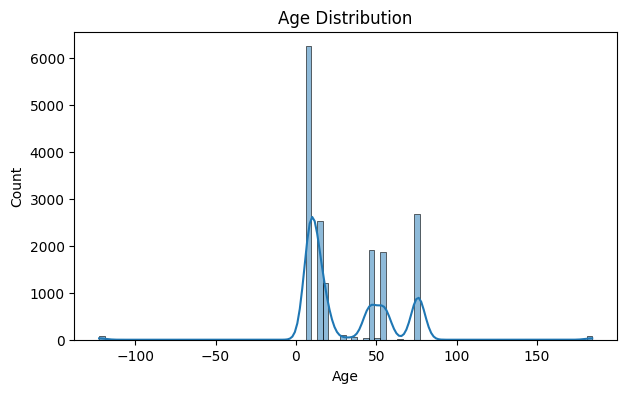

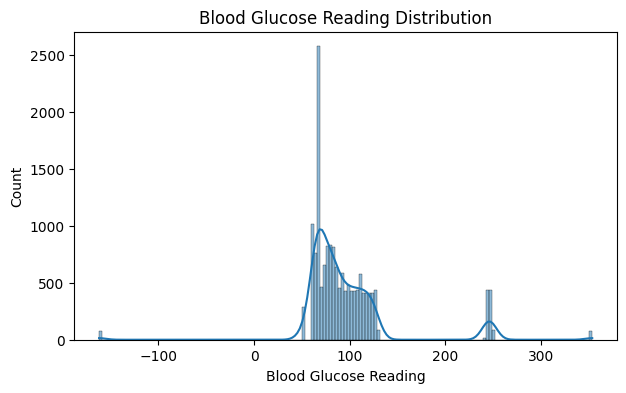

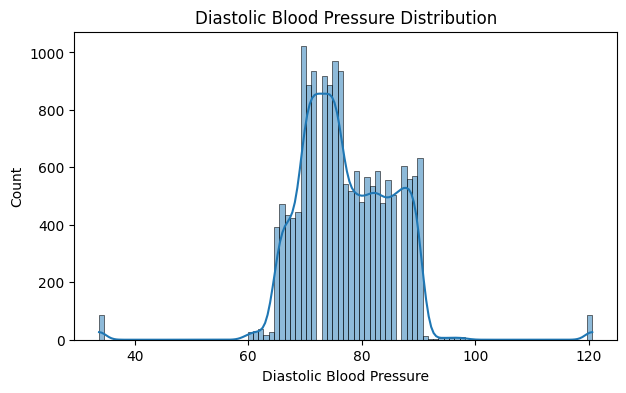

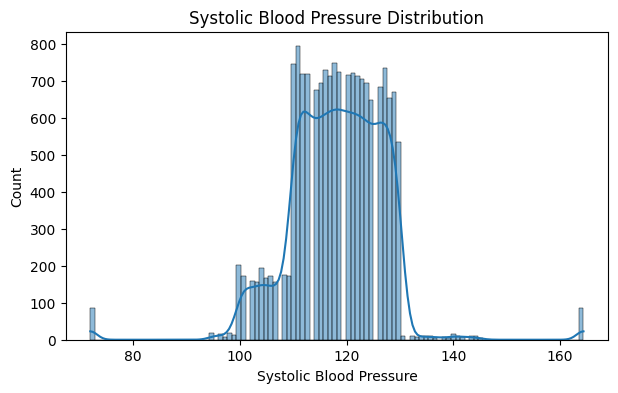

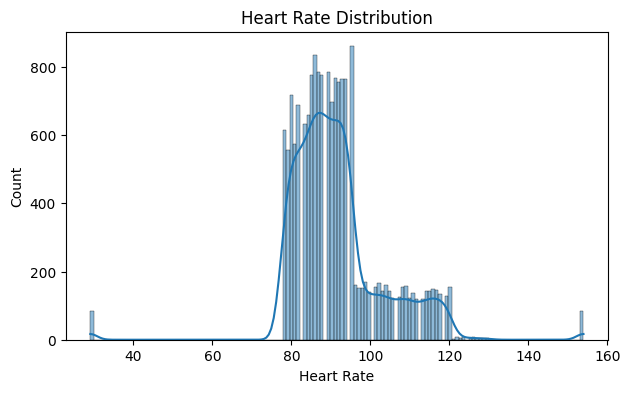

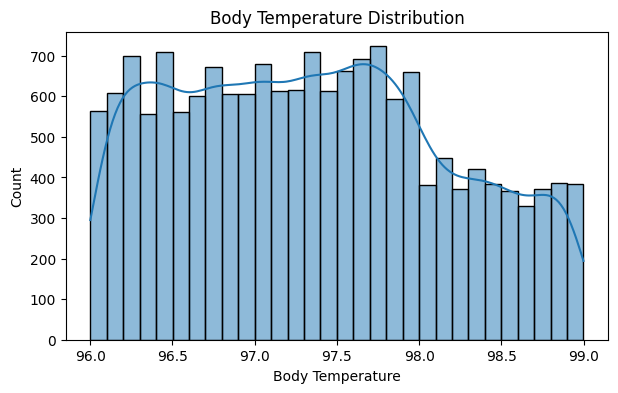

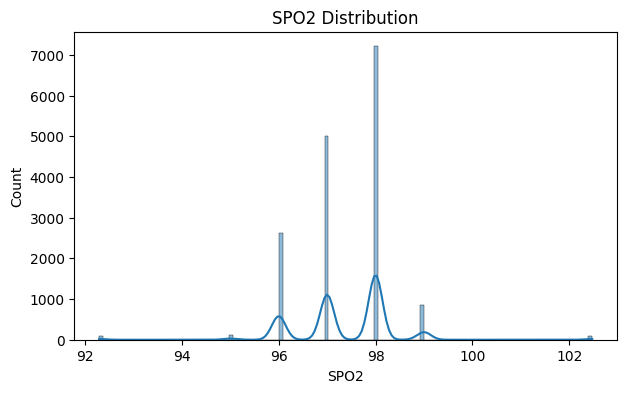

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [68]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean['Age'] >= 0) &
    (df_clean['Age'] <= 100)
]

df_clean = df_clean[
    df_clean['Blood Glucose Reading'] >= 0

]

df_clean = df_clean[
    df_clean['Sweating  (Y/N)'].isin([0, 1]) &
    df_clean['Shivering (Y/N)'].isin([0, 1])
].copy()

df_clean['Sweating  (Y/N)'] = df_clean['Sweating  (Y/N)'].astype(int)
df_clean['Shivering (Y/N)'] = df_clean['Shivering (Y/N)'].astype(int)


print("Before cleaning:")
print("Min SPO2:", df_clean['SPO2'].min())
print("Max SPO2:", df_clean['SPO2'].max())
print("Rows before:", df_clean.shape[0])

invalid_spo2 = df_clean[
    (df_clean['SPO2'] < 0) | 
    (df_clean['SPO2'] > 100)
]
print("Invalid SPO2 count:", invalid_spo2.shape[0])
invalid_spo2[['SPO2']].head()

df_clean = df_clean[
    (df_clean['SPO2'] >= 0) &
    (df_clean['SPO2'] <= 100)
].copy()


Before cleaning:
Min SPO2: 92.28743596975988
Max SPO2: 102.47628836495882
Rows before: 15421
Invalid SPO2 count: 75


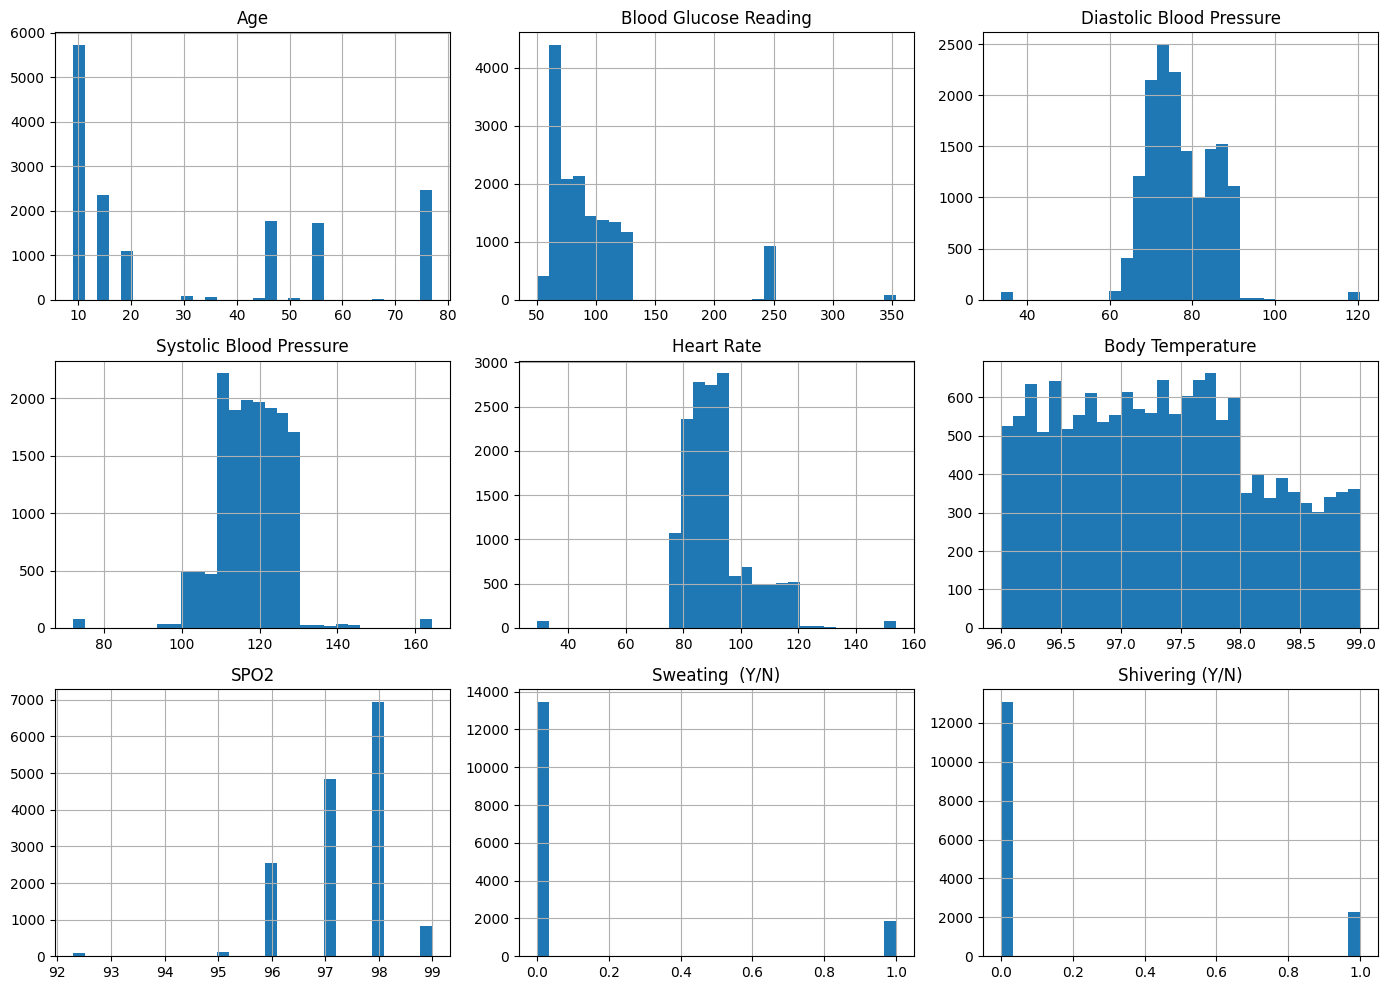

In [69]:
df_clean.hist(
    bins=30,
    figsize=(14, 10),
    grid=True
)

plt.tight_layout()
plt.show()

In [70]:
df_clean['Sweating  (Y/N)'].unique()

array([0, 1])

In [71]:
df_clean['Shivering (Y/N)'].unique()

array([0, 1])

In [72]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

In [73]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


<function matplotlib.pyplot.show(close=None, block=None)>

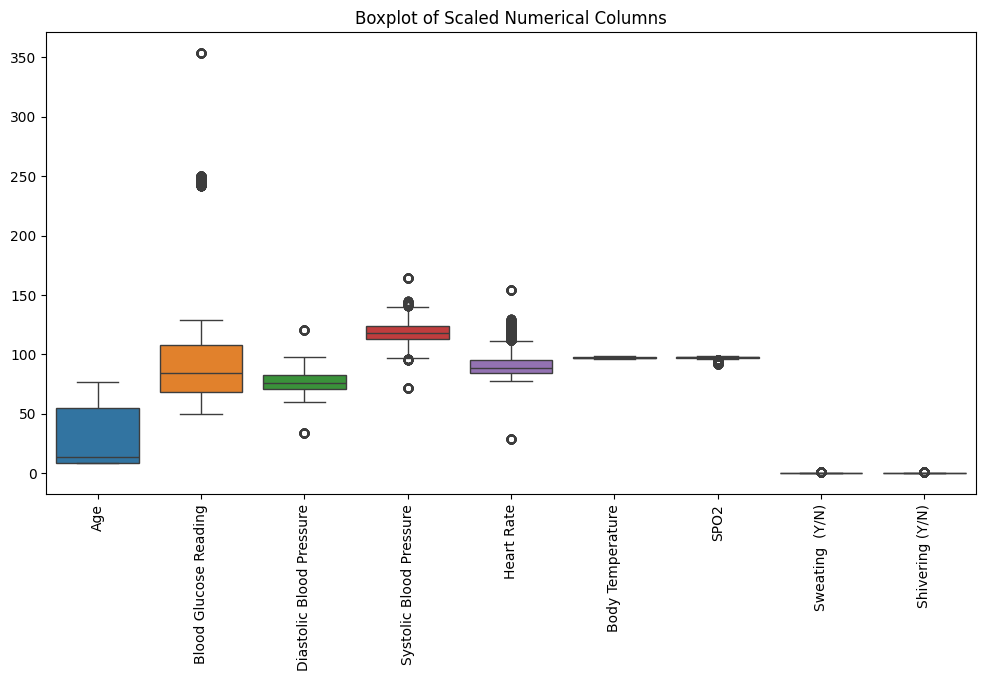

In [74]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

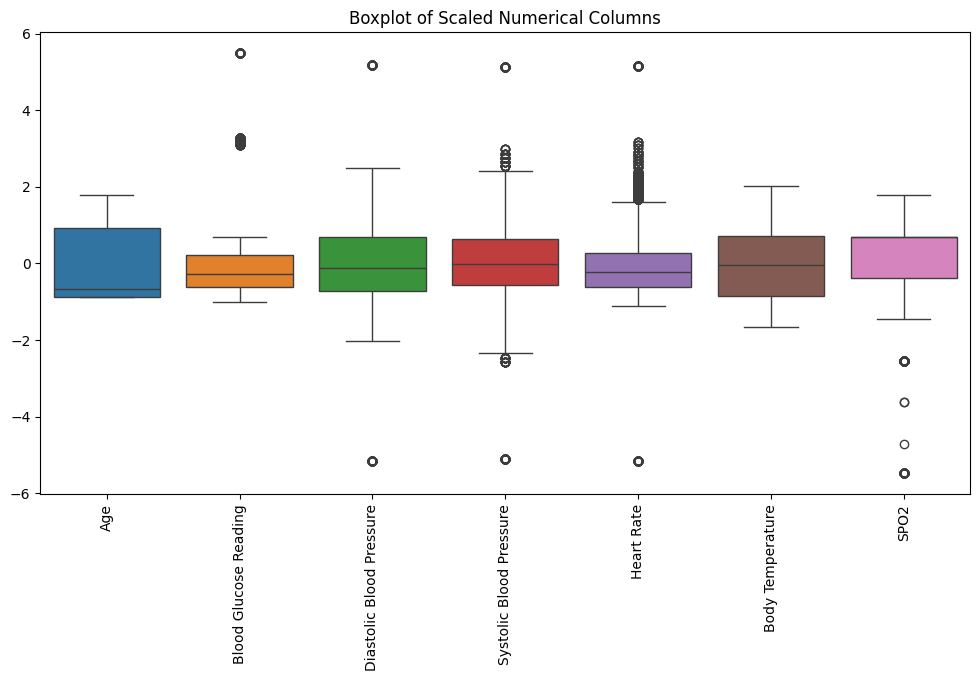

In [75]:
#boxplot 
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled=scaler.fit_transform(df_clean[num_col])
df_clean_scaled=pd.DataFrame(scaled,columns=num_col)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean_scaled)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show

0 = average value
negative value = below average
positive value = above average

In [76]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [77]:
total_outliers = []

for col in num_col:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    total_outliers.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers.shape[0]
    })

iqr_df = pd.DataFrame(total_outliers)

iqr_df

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,9.000000,55.000000,46.000000,-60.000000,124.000000,0
1,Blood Glucose Reading,68.000000,108.000000,40.000000,8.000000,168.000000,1010
2,Diastolic Blood Pressure,71.000000,83.000000,12.000000,53.000000,101.000000,153
3,Systolic Blood Pressure,113.000000,124.000000,11.000000,96.500000,140.500000,230
4,Heart Rate,84.000000,95.000000,11.000000,67.500000,111.500000,1346
5,Body Temperature,96.674465,97.951796,1.277331,94.758469,99.867792,0
6,SPO2,97.000000,98.000000,1.000000,95.500000,99.500000,203


In [78]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [79]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


In [80]:
df_clean.duplicated().sum()

np.int64(0)

In [81]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

## Categorical features

In [82]:
target = 'Diabetic/NonDiabetic (D/N)'

cat_col = [
    'Gender',
    'Diastolic Blood Pressure Level'
]

binary_cols = [
    'Sweating  (Y/N)',
    'Shivering (Y/N)'
]

all_cat_col = cat_col + binary_cols

print("cat_col:", cat_col)
print("binary_cols:", binary_cols)
print("all_cat_col:", all_cat_col)

cat_col: ['Gender', 'Diastolic Blood Pressure Level']
binary_cols: ['Sweating  (Y/N)', 'Shivering (Y/N)']
all_cat_col: ['Gender', 'Diastolic Blood Pressure Level', 'Sweating  (Y/N)', 'Shivering (Y/N)']


In [83]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


In [84]:
for col in all_cat_col:
    print(col)
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True) * 100)
    print("------------------")

Gender
Gender
M    10563
F     4701
Name: count, dtype: int64
Gender
M    69.202044
F    30.797956
Name: proportion, dtype: float64
------------------
Diastolic Blood Pressure Level
Diastolic Blood Pressure Level
High      15246
Low          81
Medium        1
Name: count, dtype: int64
Diastolic Blood Pressure Level
High      99.465031
Low        0.528445
Medium     0.006524
Name: proportion, dtype: float64
------------------
Sweating  (Y/N)
Sweating  (Y/N)
0    13464
1     1882
Name: count, dtype: int64
Sweating  (Y/N)
0    87.736218
1    12.263782
Name: proportion, dtype: float64
------------------
Shivering (Y/N)
Shivering (Y/N)
0    13085
1     2261
Name: count, dtype: int64
Shivering (Y/N)
0    85.266519
1    14.733481
Name: proportion, dtype: float64
------------------


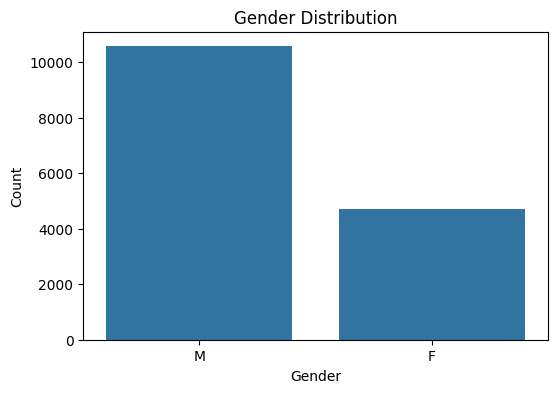

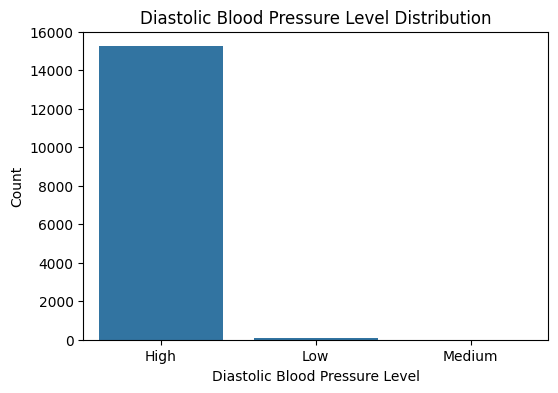

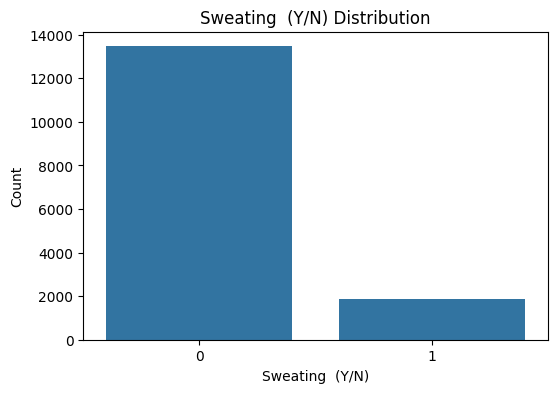

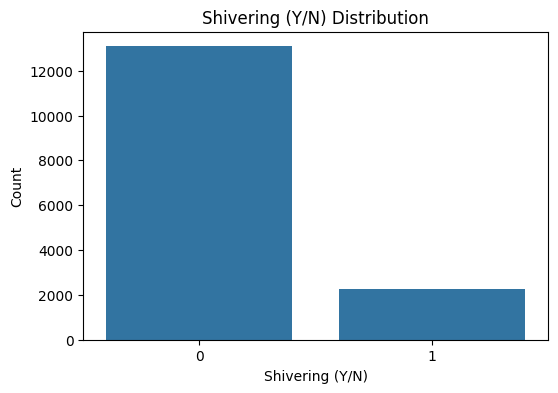

In [85]:

for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df_clean)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

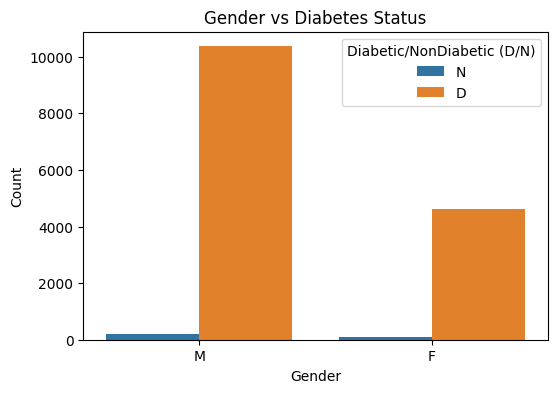

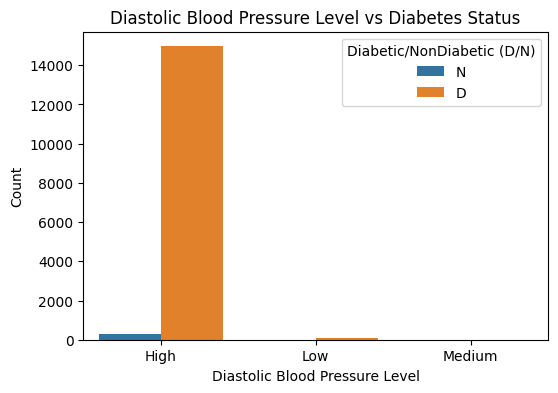

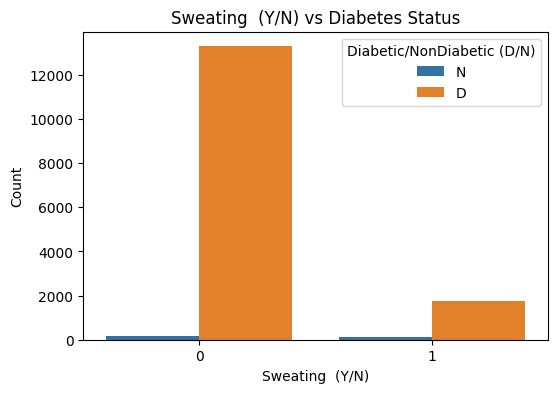

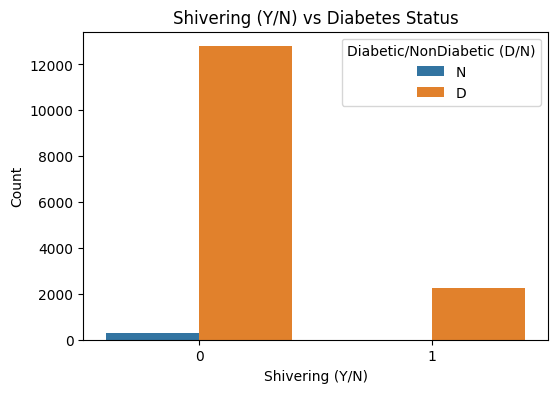

In [86]:
target = 'Diabetic/NonDiabetic (D/N)'

for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=target, data=df_clean)
    plt.title(f'{col} vs Diabetes Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [87]:
for col in all_cat_col:
    print(col)
    print(pd.crosstab(df_clean[col], df_clean[target]))
    print()
    print(pd.crosstab(df_clean[col], df_clean[target], normalize='index') * 100)
    print("----------------------")

Gender
Diabetic/NonDiabetic (D/N)      D    N
Gender                                
F                            4611   90
M                           10365  198

Diabetic/NonDiabetic (D/N)          D         N
Gender                                         
F                           98.085514  1.914486
M                           98.125533  1.874467
----------------------
Diastolic Blood Pressure Level
Diabetic/NonDiabetic (D/N)          D    N
Diastolic Blood Pressure Level            
High                            14962  284
Low                                72    9
Medium                              0    1

Diabetic/NonDiabetic (D/N)              D           N
Diastolic Blood Pressure Level                       
High                            98.137216    1.862784
Low                             88.888889   11.111111
Medium                           0.000000  100.000000
----------------------
Sweating  (Y/N)
Diabetic/NonDiabetic (D/N)      D    N
Sweating  (Y/N)           

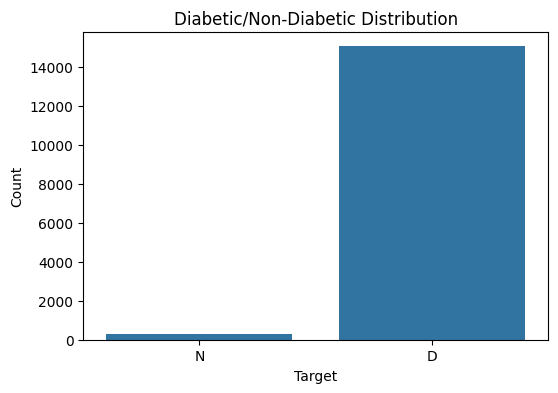

In [88]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df_clean)
plt.title('Diabetic/Non-Diabetic Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [89]:
df_clean['Diabetic/NonDiabetic (D/N)'].value_counts()

Diabetic/NonDiabetic (D/N)
D    15048
N      298
Name: count, dtype: int64

In [90]:
df_clean['Diabetic/NonDiabetic (D/N)'].isnull().sum()

np.int64(0)

In [91]:
from scipy.stats import chi2_contingency
import pandas as pd

chi_results = []

for col in all_cat_col:
    observed = pd.crosstab(df_clean[col], df_clean[target])
    
    chi2, p_value, dof, expected = chi2_contingency(observed)
    
    chi_results.append({
        'Feature': col,
        'Chi_square_statistic': chi2,
        'p_value': p_value,
        'Degree_of_freedom': dof,
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })

chi_df = pd.DataFrame(chi_results).sort_values(by='p_value')
chi_df

,Feature,Chi_square_statistic,p_value,Degree_of_freedom,Result
2,Sweating (Y/N),286.762723,2.523150e-64,1,Significant
1,Diastolic Blood Pressure Level,87.771277,8.723875e-20,2,Significant
3,Shivering (Y/N),51.322907,7.835598e-13,1,Significant
0,Gender,0.010677,9.176999e-01,1,Not Significant


In [92]:
import numpy as np
from scipy.stats import chi2_contingency

cramers_results = []

for col in all_cat_col:
    table = pd.crosstab(df_clean[col], df_clean[target])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    n = table.sum().sum()
    r, k = table.shape
    
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    
    cramers_results.append({
        'Feature': col,
        'Chi_square': chi2,
        'p_value': p_value,
        'Cramers_V': cramers_v
    })

cramers_df = pd.DataFrame(cramers_results).sort_values(by='Cramers_V', ascending=False)
cramers_df

,Feature,Chi_square,p_value,Cramers_V
2,Sweating (Y/N),286.762723,2.523150e-64,0.136699
1,Diastolic Blood Pressure Level,87.771277,8.723875e-20,0.075672
3,Shivering (Y/N),51.322907,7.835598e-13,0.057831
0,Gender,0.010677,9.176999e-01,0.000836


The Chi-square test shows that Sweating, Diastolic Blood Pressure Level, and Shivering have statistically significant associations with diabetes status. However, Cramer’s V values are low, indicating weak relationship strength. Gender is not statistically significant and has almost no association with diabetes status.

## Numerical features vs Target

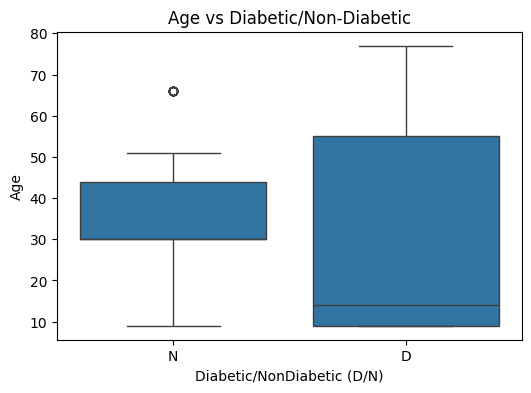

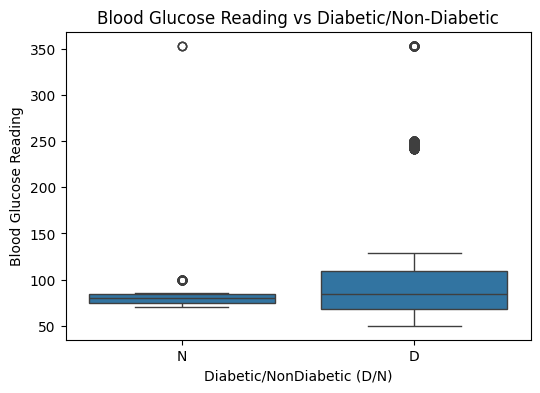

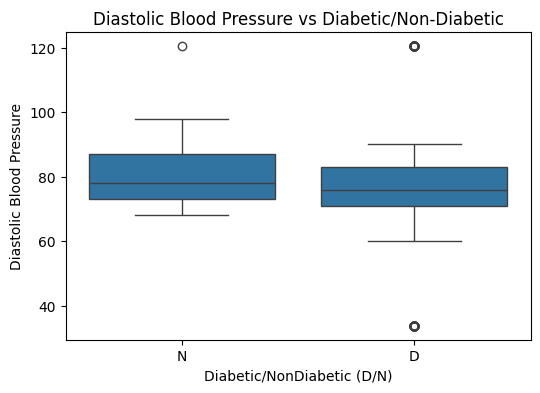

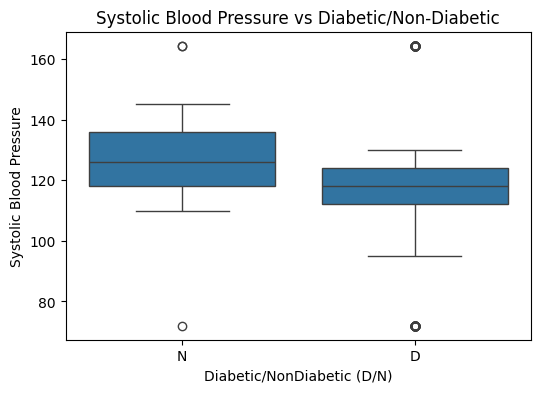

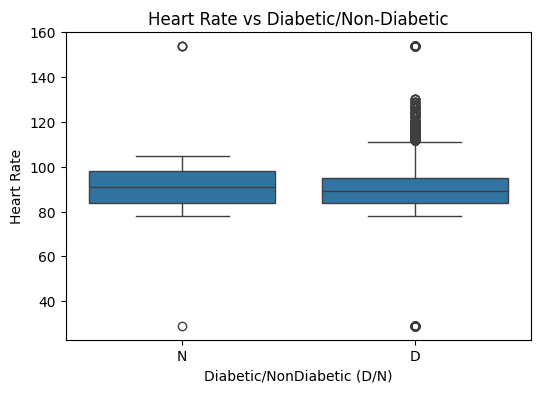

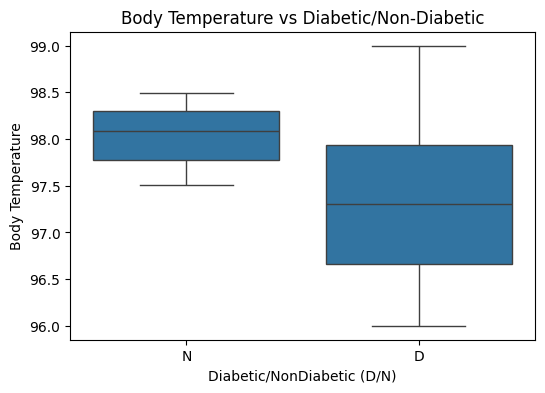

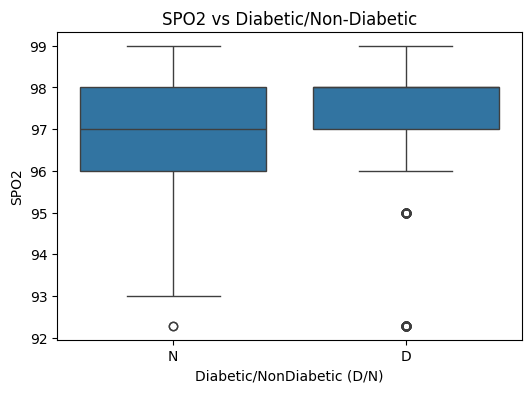

In [93]:
for col in num_col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df_clean)
    plt.title(f'{col} vs Diabetic/Non-Diabetic')
    plt.xlabel(target)
    plt.ylabel(col)
    plt.show()

In [94]:
from scipy.stats import ttest_ind
import pandas as pd

t_test_results = []

for col in num_col:
    group_D = df_clean[df_clean[target] == 'D'][col].dropna()
    group_N = df_clean[df_clean[target] == 'N'][col].dropna()
    
    t_stat, p_value = ttest_ind(group_D, group_N, equal_var=False)
    
    t_test_results.append({
        'Feature': col,
        'Diabetic_Mean': group_D.mean(),
        'NonDiabetic_Mean': group_N.mean(),
        'Mean_Difference': group_D.mean() - group_N.mean(),
        't_statistic': t_stat,
        'p_value': p_value,
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })

t_test_df = pd.DataFrame(t_test_results).sort_values(by='p_value')
t_test_df

,Feature,Diabetic_Mean,NonDiabetic_Mean,Mean_Difference,t_statistic,p_value,Result
5,Body Temperature,97.346051,98.033351,-0.687299,-37.024004,5.703629e-128,Significant
3,Systolic Blood Pressure,117.975864,127.371690,-9.395826,-14.803903,9.727575e-38,Significant
1,Blood Glucose Reading,97.403903,84.827171,12.576732,7.344132,1.641580e-12,Significant
2,Diastolic Blood Pressure,77.045868,80.383070,-3.337202,-6.401351,5.842246e-10,Significant
6,SPO2,97.360702,96.931459,0.429243,4.844445,2.034802e-06,Significant
0,Age,31.102539,32.036913,-0.934374,-1.004658,3.157982e-01,Not Significant
4,Heart Rate,91.617723,91.389309,0.228414,0.354494,7.232084e-01,Not Significant


In [95]:
from scipy.stats import f_oneway
import pandas as pd

f_test_results = []

for col in num_col:
    group_D = df_clean[df_clean[target] == 'D'][col].dropna()
    group_N = df_clean[df_clean[target] == 'N'][col].dropna()
    
    f_stat, p_value = f_oneway(group_D, group_N)
    
    f_test_results.append({
        'Feature': col,
        'F_statistic': f_stat,
        'p_value': p_value,
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })

f_test_df = pd.DataFrame(f_test_results).sort_values(by='p_value')
f_test_df

,Feature,F_statistic,p_value,Result
3,Systolic Blood Pressure,323.780388,1.184460e-71,Significant
5,Body Temperature,203.838366,6.033493e-46,Significant
6,SPO2,63.284966,1.912813e-15,Significant
2,Diastolic Blood Pressure,45.574590,1.522126e-11,Significant
1,Blood Glucose Reading,21.215015,4.138354e-06,Significant
0,Age,0.389587,5.325260e-01,Not Significant
4,Heart Rate,0.103800,7.473209e-01,Not Significant


In [96]:
for col in num_col:
    print(col)
    print(df_clean.groupby(target)[col].mean())
    print("----------------------")

Age
Diabetic/NonDiabetic (D/N)
D    31.102539
N    32.036913
Name: Age, dtype: float64
----------------------
Blood Glucose Reading
Diabetic/NonDiabetic (D/N)
D    97.403903
N    84.827171
Name: Blood Glucose Reading, dtype: float64
----------------------
Diastolic Blood Pressure
Diabetic/NonDiabetic (D/N)
D    77.045868
N    80.383070
Name: Diastolic Blood Pressure, dtype: float64
----------------------
Systolic Blood Pressure
Diabetic/NonDiabetic (D/N)
D    117.975864
N    127.371690
Name: Systolic Blood Pressure, dtype: float64
----------------------
Heart Rate
Diabetic/NonDiabetic (D/N)
D    91.617723
N    91.389309
Name: Heart Rate, dtype: float64
----------------------
Body Temperature
Diabetic/NonDiabetic (D/N)
D    97.346051
N    98.033351
Name: Body Temperature, dtype: float64
----------------------
SPO2
Diabetic/NonDiabetic (D/N)
D    97.360702
N    96.931459
Name: SPO2, dtype: float64
----------------------


In [97]:
import numpy as np
import pandas as pd

effect_results = []

for col in num_col:
    group_D = df_clean[df_clean[target] == 'D'][col].dropna()
    group_N = df_clean[df_clean[target] == 'N'][col].dropna()
    
    mean_diff = group_D.mean() - group_N.mean()
    
    pooled_std = np.sqrt(
        ((group_D.std() ** 2) + (group_N.std() ** 2)) / 2
    )
    
    cohens_d = mean_diff / pooled_std
    
    effect_results.append({
        'Feature': col,
        'Mean_Difference': mean_diff,
        'Cohens_d': cohens_d,
        'Effect_Size': (
            'Small' if abs(cohens_d) < 0.2 else
            'Medium' if abs(cohens_d) < 0.5 else
            'Large'
        )
    })

effect_df = pd.DataFrame(effect_results).sort_values(
    by='Cohens_d',
    key=abs,
    ascending=False
)

effect_df

,Feature,Mean_Difference,Cohens_d,Effect_Size
5,Body Temperature,-0.687299,-1.120830,Large
3,Systolic Blood Pressure,-9.395826,-0.945779,Large
2,Diastolic Blood Pressure,-3.337202,-0.386848,Medium
6,SPO2,0.429243,0.342302,Medium
1,Blood Glucose Reading,12.576732,0.322824,Medium
0,Age,-0.934374,-0.043863,Small
4,Heart Rate,0.228414,0.019725,Small


Cohen’s d was used to measure the practical strength of the difference between Diabetic and Non-Diabetic groups. Body Temperature and Systolic Blood Pressure showed large effect sizes, indicating strong group differences. Diastolic Blood Pressure, SPO2, and Blood Glucose Reading showed medium effect sizes. Age and Heart Rate showed very small effect sizes, meaning they may not be very useful for separating diabetic and non-diabetic records.

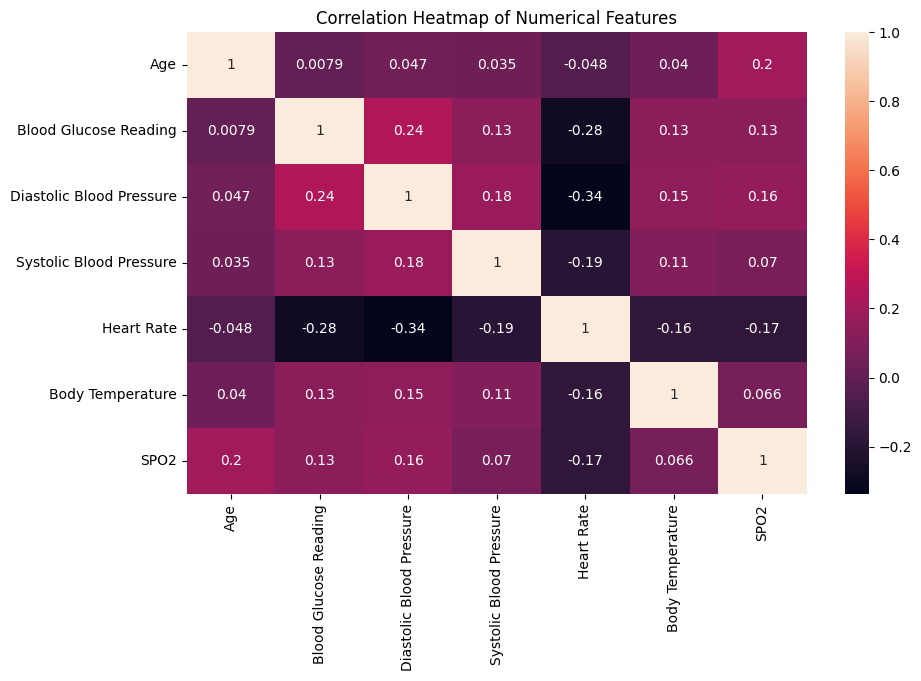

In [98]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[num_col].corr(), annot=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### EDA Insights

EDA insight:
The dataset required cleaning because some columns contained impossible medical values. After cleaning, the dataset became more suitable for analysis and modeling.

D = 15048
N = 298
The target variable is highly imbalanced. Diabetic cases dominate the dataset, while Non-Diabetic cases are very low. This may cause a machine learning model to become biased toward predicting the majority class. Therefore, accuracy alone should not be used for model evaluation.


The numerical features are not perfectly normally distributed. Blood Glucose Reading shows right skewness and high outliers. Several medical features contain extreme values, but because this is medical data, outliers may represent real patient conditions and should not be removed blindly.


IQR analysis showed that Blood Glucose Reading and Heart Rate contain many outliers. However, in medical datasets, outliers do not always mean incorrect values. They may represent abnormal but real patient conditions.


The Chi-square test shows that Sweating, Diastolic Blood Pressure Level, and Shivering have statistically significant associations with diabetes status. Gender does not show a significant association with diabetes status in this dataset.



Although Sweating, Diastolic Blood Pressure Level, and Shivering are statistically significant, their Cramer’s V values are low. This means their relationship strength with diabetes status is weak. Gender has almost no association with the target.


Boxplots showed visible differences in Blood Glucose Reading, Body Temperature, and Blood Pressure between Diabetic and Non-Diabetic groups. However, statistical testing was needed to confirm whether these differences were significant.

EDA insight:
Welch’s t-test showed that Body Temperature, Systolic Blood Pressure, Blood Glucose Reading, Diastolic Blood Pressure, and SPO2 are statistically different between Diabetic and Non-Diabetic groups. Age and Heart Rate are not statistically significant in this dataset.

EDA insight:
Cohen’s d showed that Body Temperature and Systolic Blood Pressure have the strongest practical differences between Diabetic and Non-Diabetic groups. Diastolic Blood Pressure, SPO2, and Blood Glucose Reading have medium effect sizes. Age and Heart Rate have very small effect sizes, meaning they may not be very useful for separating the target classes.

EDA insight:
The correlation heatmap shows mostly weak relationships among numerical features. The strongest relationship is between Heart Rate and Diastolic Blood Pressure with a moderate negative correlation of -0.34. Overall, there is no serious multicollinearity problem among the numerical features.

Final EDA Summary:
The dataset is highly imbalanced, with diabetic records much higher than non-diabetic records. Numerical analysis showed that Body Temperature, Systolic Blood Pressure, Blood Glucose Reading, Diastolic Blood Pressure, and SPO2 are significantly different between diabetic and non-diabetic groups. Age and Heart Rate are not strongly related to the target. Categorical analysis showed that Sweating, Shivering, and Diastolic Blood Pressure Level are statistically associated with diabetes status, while Gender is not significant. Outliers are present in several medical features, but they may represent real patient conditions. Correlation analysis showed no serious multicollinearity. Model evaluation should focus on recall, precision, F1-score, and balanced accuracy because the target variable is highly imbalanced.

In [99]:
df_model = df_clean.copy()

In [100]:
target = 'Diabetic/NonDiabetic (D/N)'

df_model[target] = df_model[target].astype(str).str.strip()

df_model['Diabetic_Target'] = df_model[target].map({
    'N': 0,
    'D': 1
})

df_model[['Diabetic/NonDiabetic (D/N)', 'Diabetic_Target']].head()

df_model['Diabetic_Target'].value_counts()

Diabetic_Target
1    15048
0      298
Name: count, dtype: int64

In [101]:
df_model.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N),Diabetic_Target
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N,0
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N,0
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N,0
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N,0
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N,0
